In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.458,0.456,0.406],
                        [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.458,0.456,0.406],
                        [0.229, 0.224, 0.225])
])

In [6]:
train_dataset = datasets.ImageFolder(root = 'seg_train', transform = train_transform)
test_dataset = datasets.ImageFolder(root = 'seg_test', transform = test_transform)

In [8]:
train_load = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_load = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [10]:
device = torch.device('cuda' if torch.cuda.is_available else "cpu")

In [12]:
model = models.resnet50(pretrained = True)


C:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
for param in model.parameters():
    param.requires_grad = False
num_fc = model.fc.in_features
model.fc = nn.Linear(num_fc, 6)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(),lr = 0.001)

In [18]:
epochs = 10
for epoch in range(epochs):
    model.train()
    total = 0
    r_loss = 0
    correct = 0
    for image , label in train_load:
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        r_loss += loss.item()
        total += label.size(0)
        _, predict = torch.max(output, 1)
        correct += (predict == label).sum().item()
    acc = 100*correct/total
    print(f"[{epoch+1}/{epochs}] , loss: {r_loss/len(train_load):.6f}, acc: {acc: .4f}")

[1/10] , loss: 0.414124, acc:  85.4069
[2/10] , loss: 0.285360, acc:  89.6394
[3/10] , loss: 0.280744, acc:  89.8461
[4/10] , loss: 0.265568, acc:  90.2736
[5/10] , loss: 0.253105, acc:  90.6727
[6/10] , loss: 0.254485, acc:  90.4731
[7/10] , loss: 0.244551, acc:  90.8080
[8/10] , loss: 0.244378, acc:  90.8864
[9/10] , loss: 0.241456, acc:  91.0646
[10/10] , loss: 0.231255, acc:  91.6417


In [20]:
model.eval()
crr = 0
t = 0
with torch.no_grad():
    for image, label in test_load:
        image, label = image.to(device), label.to(device)
        oput = model(image)
        _, pred = torch.max(oput,1)
        t += label.size(0)
        crr +=(pred == label).sum().item()
print(f"test acc : {100*crr/t:.4f}")
        

test acc : 90.8667


In [22]:
from PIL import Image
import os 
import random
import matplotlib.pyplot as plt

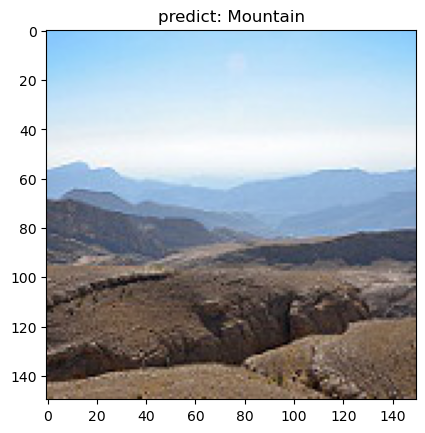

In [42]:
folder = 'seg_pred'
img_n = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_n)
image = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
input_tensor = transform(image).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    oput = model(input_tensor)
    _, pred = torch.max(oput,1)
class_place = ['Building', 'Forest', 'Glacier', 'Mountain', 'Sea', 'Street']
pred_label = class_place[pred.item()]
plt.imshow(image)
plt.title(f"predict: {pred_label}")
plt.show()

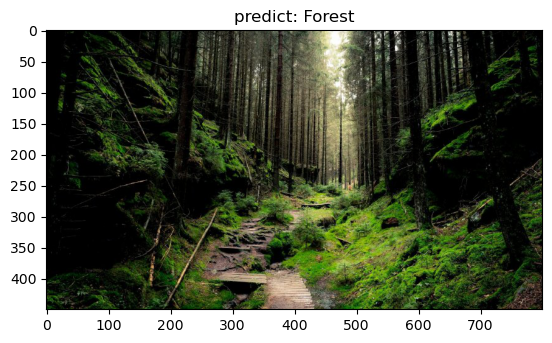

In [44]:
image = Image.open('forest.jpg').convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
input_tensor = transform(image).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    oput = model(input_tensor)
    _, pred = torch.max(oput,1)
class_place = ['Building', 'Forest', 'Glacier', 'Mountain', 'Sea', 'Street']
pred_label = class_place[pred.item()]
plt.imshow(image)
plt.title(f"predict: {pred_label}")
plt.show()